# <center> TP5 : Reconnaissance de Formes </center>

<div class="alert alert-block alert-warning">
    Transformée de Hough
</div>


# Hough Space

<img src="images/Hough.jpg" width="600">


### <span style="color:crimson">**[Exercice ]**:</span>
---

<div style="color:DarkSlateBlue">  

Compléter l'algoritme ci-dessous qui utilise la transformée de Hough pour détecter des lignes dans l'image.


Vous devez analyser l'image afin de détecter les lignes présentes. Pour cela, vous utiliserez :

__Étapes à réaliser :__

Chargement et prétraitement de l'image :
- Chargez une image contenant des lignes à détecter.
- Convertissez l'image en niveaux de gris pour simplifier l'analyse.
- Appliquez l'algorithme de détection des contours de Canny.

Construction de la matrice d'accumulation de Hough :
- Implémentez une matrice d'accumulation pour représenter les paramètres de la transformation de Hough (rho et theta).
- Calculez et remplissez cette matrice à l’aide des pixels de contours détectés.

Détection des lignes avec la transformation de Hough :
- Utilisez la fonction cv2.HoughLinesP pour identifier les segments de ligne dans l’image.
- Ajustez les paramètres pour obtenir une détection précise des lignes.

Affichage des résultats :
- Visualisez :
        - Les contours détectés.
        - La matrice d’accumulation de Hough.
        - L’image originale avec les lignes détectées dessinées.


</div>



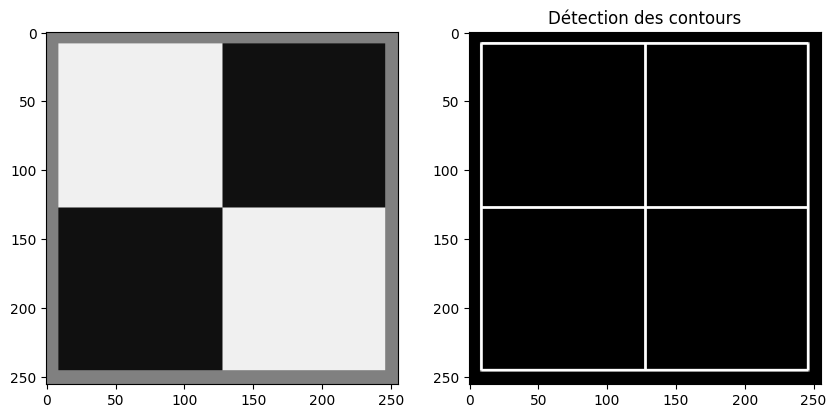

In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from skimage.feature import peak_local_max

Box = cv2.imread('images/Boxes.png')
# A compléter
sobelx = cv2.Sobel(Box, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(Box, cv2.CV_64F, 0, 1, ksize=3)
Box_edges = cv2.magnitude(sobelx, sobely)
Box_edges = cv2.convertScaleAbs(Box_edges)

plt.figure(figsize=(10,10))
plt.subplot(1, 2, 1)
plt.imshow(Box, cmap='gray')
plt.subplot(1, 2, 2)
plt.imshow(Box_edges, cmap="gray")
plt.title('Détection des contours')
plt.show()

In [3]:
nbx, nby, _ = np.nonzero(Box_edges)

print(nbx)

[  8   8   8 ... 246 246 246]


In [4]:
image = Box_edges

def hough_transform(image):
    width = image.shape[1]
    height = image.shape[0]
    
    taille = np.sqrt(height**2 + width**2)
    diag_len = np.ceil(taille)
    acc = np.zeros([int(2 * diag_len), 180])
    nbx, nby, _ = np.nonzero(image)
    for k in range(len(nbx)):
            x = nbx[k]
            y = nby[k]
            for theta in range(0, 180):
                rho = int(x * np.cos(np.deg2rad(theta)) + y * np.sin(np.deg2rad(theta)) + diag_len)
                acc[rho, theta] += 1

    hough_accu = acc
    return hough_accu
hough_accu = hough_transform(image)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


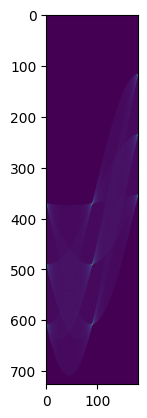

In [5]:
print(hough_accu)
plt.imshow(hough_accu)

In [6]:
print(peak_local_max(hough_accu, min_distance=45, num_peaks=6))

[[371  90]
 [490  90]
 [608  90]]


In [7]:
# Peak finding
def peak_finding(hough_accu, min_distance = 45, max_peaks = 6, title ='Hough Transform'):

    # histogramme pour trouver les pics
    # ou on trie les valeurs de la matrice et on prendsles deux trois premieres valeurs (les valeurs max)
    matrice = peak_local_max(hough_accu, min_distance=min_distance, num_peaks=max_peaks)
    loca_maxs_rho = matrice[:, 0]
    loca_maxs_theta = matrice[:, 1]
    
    return loca_maxs_rho, loca_maxs_theta

In [8]:
print(peak_finding(hough_accu))

(array([371, 490, 608]), array([90, 90, 90]))


In [13]:
def draw_line(image, loca_maxs_rho, loca_maxs_theta, rgb = (0,255,0)):
    image_copy = image.copy()
    width = image_copy.shape[1]
    height = image_copy.shape[0]
    # A compléter
    # ...
    # ...
    for i in range(len(loca_maxs_rho)):
        rho = loca_maxs_rho[i]
        theta = loca_maxs_theta[i]
        a = np.cos(np.deg2rad(theta))
        b = np.sin(np.deg2rad(theta))
        x1 = int(rho  + 1000 * (-b))
        y1 = int(theta * a + 1000 * (b))
        x2 = int(rho * a - 1000 * (-b))
        y2 = int(theta * a - 1000 * (b))
        print(a, b)
        cv2.line(image_copy, (x1, y1), (x2, y2), rgb, 2)
    
    plt.imshow(image_copy)
    plt.show()
    return image_copy

6.123233995736766e-17 1.0
6.123233995736766e-17 1.0
6.123233995736766e-17 1.0


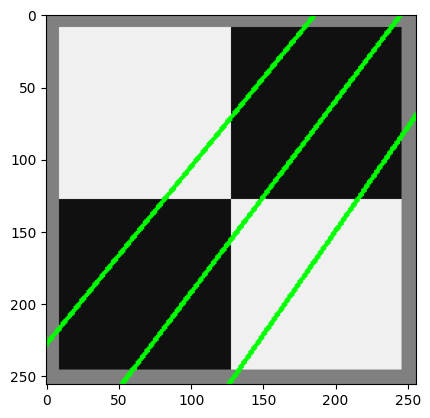

In [14]:
hough_accu = hough_transform(image)
loca_maxs_rho, loca_maxs_theta = peak_finding(hough_accu, max_peaks=50, title='Transformée de Hough')
nDraw = draw_line(Box, loca_maxs_rho, loca_maxs_theta)

In [ ]:
import ipywidgets as widgets
from IPython.display import display
# Lire l'image
img = cv2.imread('images/lanes.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convertir en RGB pour affichage
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # Convertir en niveaux de gris

# Détection des contours avec Canny pour initialiser les indices
edges = cv2.Canny(gray, 100, 200)  # Paramètres par défaut
edge_inds = np.argwhere(edges > 0)  # Indices des pixels de contour

# Initialisation des paramètres de Hough
r_step = 1
rmax = int(np.sqrt(gray.shape[0]**2 + gray.shape[1]**2))  # Hypothénuse de l'image
r_vec = np.arange(-rmax, rmax, r_step)
t_step = np.pi / 180  # Pas angulaire
t_vec = np.arange(0, np.pi, t_step)  # Vecteur theta

# Matrice d'accumulation pour Hough
acc_mat = np.zeros((len(r_vec), len(t_vec)), dtype=np.int32)

# Calcul de la matrice d'accumulation
for t_ind, t0 in enumerate(t_vec):
    for yx in edge_inds:
        # Coordonnées du pixel de contour
        # A compléter
        # ...
        # ...
        y, x = yx
        r = int(x * np.cos(t0) + y * np.sin(t0))
        r_ind = int(r + rmax)  # Convertir r en indice de la matrice d'accumulation
        if 0 <= r_ind < len(r_vec):
            acc_mat[r_ind, t_ind] += 1  # Incrémenter la matrice d'accumulation
        

# Fonction de mise à jour avec le seuil
def onTrackbarChange(th1):
    global img_rgb, gray, acc_mat, r_vec, t_vec

    th2 = th1 * 0.4  # Définir th2 comme une fraction de th1
    edges = cv2.Canny(gray, th1, th2)  # Appliquer Canny avec les nouveaux seuils

    # Détection des lignes avec HoughLinesP
    lines = cv2.HoughLinesP(edges, 2, np.pi/180.0, 50, minLineLength=10, maxLineGap=100)

    # Image pour dessiner les lignes détectées
    dst = np.copy(img_rgb)
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            cv2.line(dst, (x1, y1), (x2, y2), (255, 0, 0), 2)

    # Affichage des résultats
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    
    # Affichage des bords
    ax[0].imshow(edges, cmap='gray')
    ax[0].set_title("Bords détectés")
    ax[0].axis('off')

    # Affichage de la matrice d'accumulation
    ax[1].imshow(acc_mat, extent=[0, 180, rmax, -rmax], aspect="auto", cmap='hot')
    ax[1].set_title("Matrice d'accumulation")
    ax[1].set_xlabel("Theta (degrés)")
    ax[1].set_ylabel("R (pixels)")

    # Affichage des lignes détectées
    ax[2].imshow(dst)
    ax[2].set_title(f"Lignes détectées (Seuil: {th1})")
    ax[2].axis('off')

    plt.tight_layout()
    plt.show()

# Création d'un slider pour ajuster le seuil
threshold_slider = widgets.IntSlider(value=710, min=100, max=1000, step=10, description='Seuil:')

# Affichage du widget et mise à jour interactive
widgets.interactive(onTrackbarChange, th1=threshold_slider)


interactive(children=(IntSlider(value=710, description='Seuil:', max=1000, min=100, step=10), Output()), _dom_…

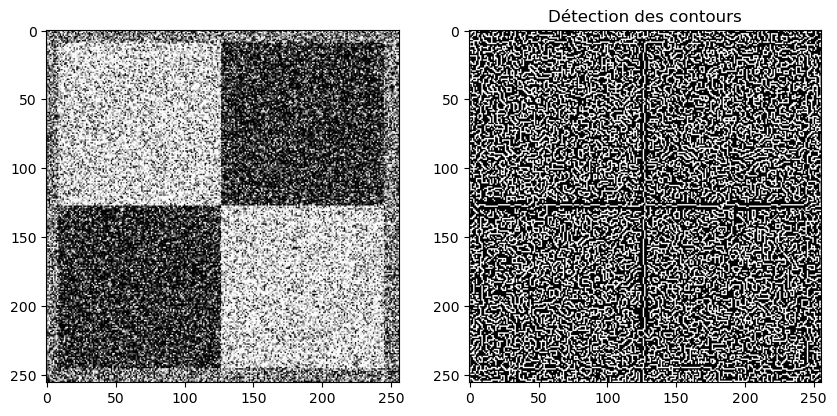

In [ ]:
nBox = cv2.imread('images/xBoxes.png')

# A compléter
# ...
# ...
sobelx = cv2.Sobel(nBox, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(nBox, cv2.CV_64F, 0, 1, ksize=3)
nBox_edges = cv2.magnitude(sobelx, sobely)
nBox_edges = cv2.convertScaleAbs(nBox_edges)

plt.figure(figsize=(10,10))
plt.subplot(1, 2, 1)
plt.imshow(nBox, cmap='gray')
plt.subplot(1, 2, 2)
plt.imshow(nBox_edges, cmap="gray")
plt.title('Détection des contours')
plt.show()

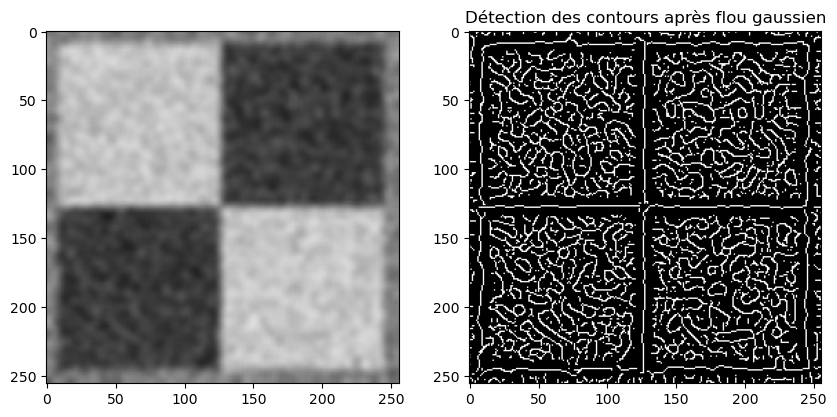

In [ ]:
GauBox = cv2.GaussianBlur(nBox, (11,11),3)

# A compléter
# ...
# ...
sobelx = cv2.Sobel(GauBox, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(GauBox, cv2.CV_64F, 0, 1, ksize=3)
nGauBox_edges = cv2.magnitude(sobelx, sobely)
nGauBox_edges = cv2.convertScaleAbs(nGauBox_edges)

plt.figure(figsize=(10,10))
plt.subplot(1, 2, 1)
plt.imshow(GauBox, cmap='gray')
plt.subplot(1, 2, 2)
plt.imshow(nGauBox_edges, cmap="gray")
plt.title('Détection des contours après flou gaussien')
plt.show()

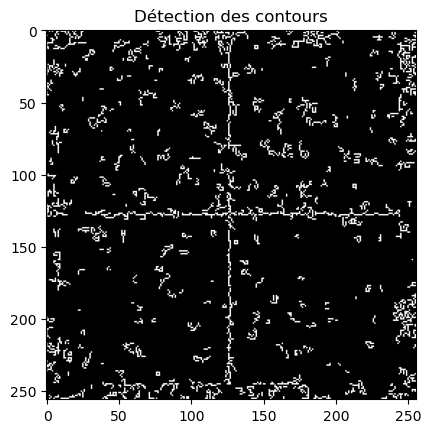

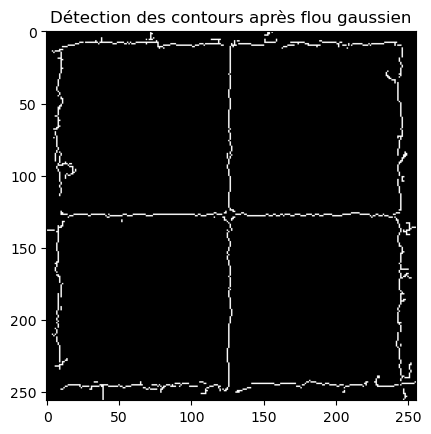

In [ ]:
# Détection des contours sur l'image bruitée
# 
# A compléter
# ...

plt.imshow(nBox_edges, cmap = 'gray')
plt.title('Détection des contours')
plt.show()

# A compléter
# ...
GauBox_edges = cv2.GaussianBlur(nBox_edges, (11,11),3)

plt.imshow(GauBox_edges, cmap='gray')
plt.title('Détection des contours après flou gaussien')
plt.show()


À partir des deux résultats obtenus, il est facile d’identifier les contours de la croix présente dans l’image.  
En revanche, dans l’image bruitée, les frontières sont difficiles à distinguer du bruit.  
On peut donc s’attendre à ce que le détecteur de droites rencontre des difficultés pour identifier ces contours.


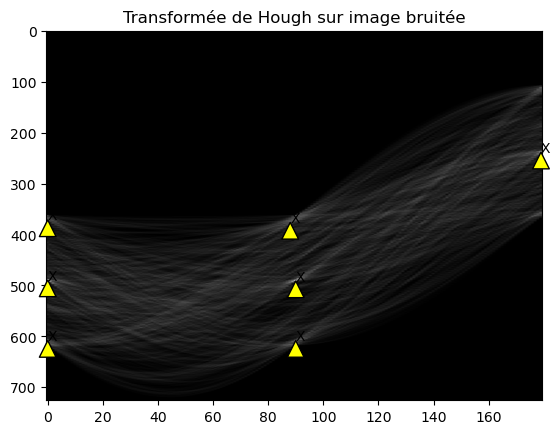

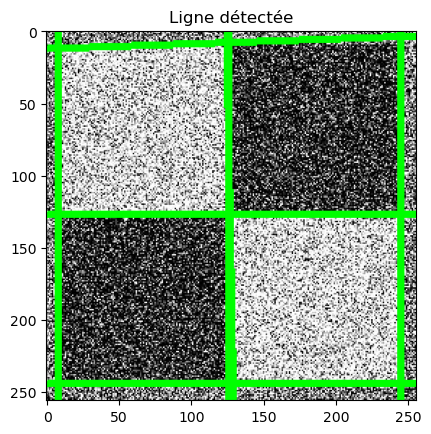

In [25]:
houghNoised = hough_transform(nBox_edges)
loca_maxs_rho, loca_maxs_theta = peak_finding(houghNoised, max_peaks=7, title = 'Transformée de Hough sur image bruitée')
HNlines = draw_line(nBox, loca_maxs_rho, loca_maxs_theta)

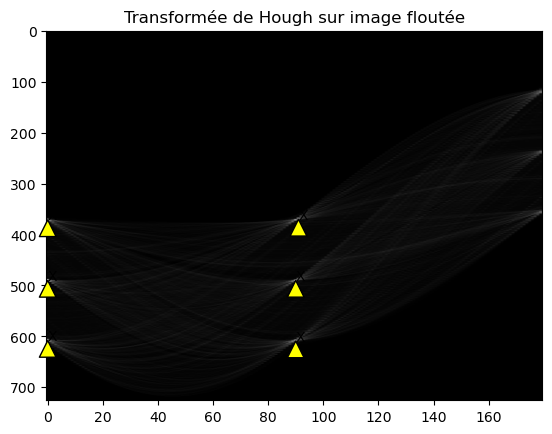

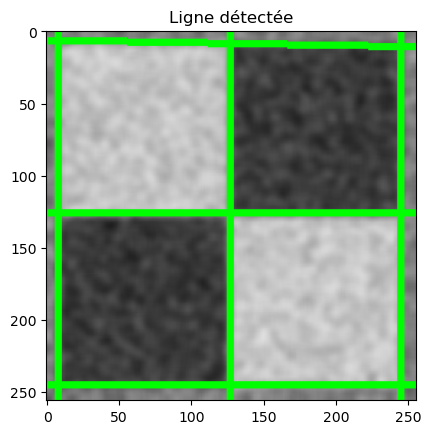

In [26]:
houghGaussian = hough_transform(GauBox_edges)
loca_maxs_rho, loca_maxs_theta = peak_finding(houghGaussian, title="Transformée de Hough sur image floutée") 
HGlines = draw_line(GauBox, loca_maxs_rho, loca_maxs_theta)

<div class="alert alert-block alert-warning">
    Transformée de Hough pour cercles
</div>

* **Cercle** : centre $(a, b)$ et rayon $r$
  \begin{equation*}
  (x_i - a)^2 + (y_i - b)^2 = r^2
  \end{equation*}

* **Pour un rayon fixé $r$**, la direction du gradient est inconnue :

<img src="./images/i1.jpg" width="500">

### Application sur l’image

<img src="images/i2.jpg" width="500">

<img src="images/i3.jpg" width="500">

* **Remarque :** une transformée de Hough différente (avec des accumulateurs séparés) a été utilisée pour chaque valeur de rayon de cercle  
  *(quarters vs. penny)*.


<div class="alert alert-block alert-warning">
    Que faire lorsque le rayon n’est pas connu ?
</div>



<img src="./images/i4.jpg" width="500">

### So that the algorithm will be..

<img src="./images/i5.jpg" width="500">



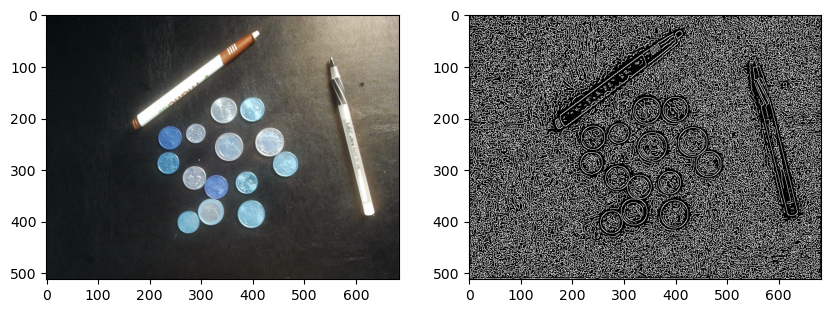

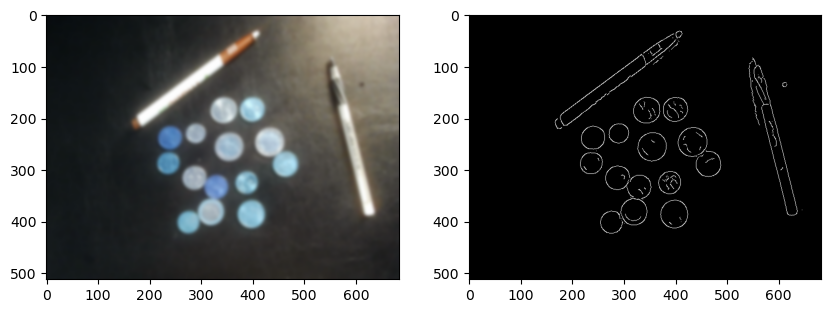

In [36]:
Box = cv2.imread('images/Input.jpg')

Box_edges = cv2.Canny(Box, 100, 200, 1, 7, True) 

plt.figure(figsize=(10,10))
plt.subplot(1, 2, 1)
plt.imshow(Box, cmap='gray')
plt.subplot(1, 2, 2)
plt.imshow(Box_edges, cmap="gray")
plt.show()
GauBox = cv2.GaussianBlur(Box, (15,15),3)

Box_edges = cv2.Canny(GauBox, 30, 40) 

plt.figure(figsize=(10,10))
plt.subplot(1, 2, 1)
plt.imshow(GauBox, cmap='gray')
plt.subplot(1, 2, 2)
plt.imshow(Box_edges, cmap="gray")
plt.show()

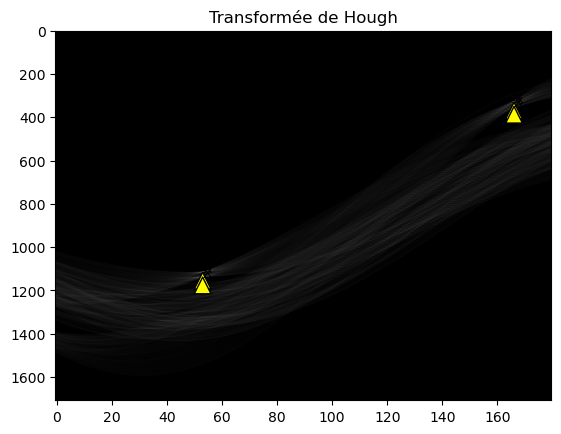

In [37]:
image = Box_edges


hough_accu = hough_transform(image)
loca_maxs_rho, loca_maxs_theta = peak_finding(hough_accu, 10, max_peaks=4, title='Transformée de Hough')

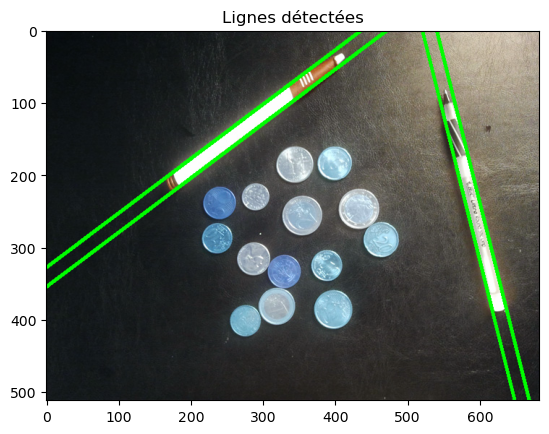

In [38]:
nDraw = draw_line(Box, loca_maxs_rho, loca_maxs_theta)

<div class="alert alert-block alert-warning">
    Application à la détection de Cercle
</div>

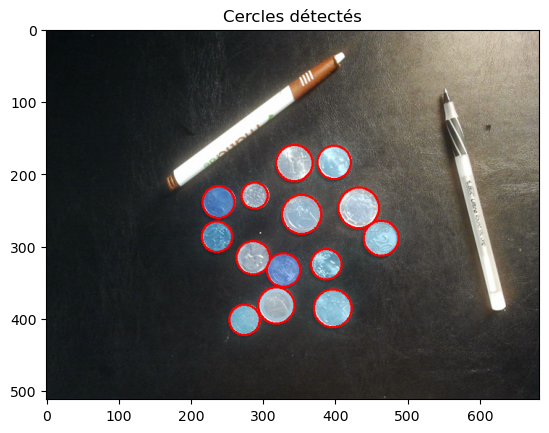

In [ ]:
def hough_transform_circle(image, image_edges, max_rad):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    height = image.shape[0]
    width = image.shape[1]

    # A compléter
    # ...
    # ...
    hough_accu = np.zeros((height, width, max_rad), dtype=np.int32)
    edge_inds = np.argwhere(image_edges > 0)

    for y, x in edge_inds:
        for r in range(1, max_rad):
            for a in range(0, width):
                b = int(np.sqrt(r**2 - (a-x)**2) + y)
                if 0 <= a < width and 0 <= b < height:
                    hough_accu[b, a, r] += 1

    return hough_accu

def peak_finding_circle(hough_accu_circle, min_dist = 20, max_peaks=10, title ='Transformée de Hough pour cercles'): 
    
    # A compléter
    # ...
    # ...
    matrice = peak_local_max(hough_accu_circle, min_distance=min_dist, num_peaks=max_peaks)
    loca_maxs_a = matrice[:, 1]  # Coordonnées a (colonnes)
    loca_maxs_b = matrice[:, 0]  # Coordonnées b (lignes)
    loca_maxs_radius = matrice[:, 2]  # Rayons correspondants aux pics trouvés
    return loca_maxs_a, loca_maxs_b, loca_maxs_radius

def draw_circle(image, loca_maxs_a, loca_maxs_b, loca_maxs_radius, min_rad = 0, max_rad = 100,  title = 'Detected Circle'):
    image_copy = image.copy()
    # A compléter
    # ...
    # ...
    for a, b, r in zip(loca_maxs_a, loca_maxs_b, loca_maxs_radius):
        if min_rad <= r <= max_rad:
            cv2.circle(image_copy, (a, b), r, (0, 255, 0), 2)
    
    return image_copy

hough_accu_circle = hough_transform_circle(Box, Box_edges, 100)
X, Y, r = peak_finding_circle(hough_accu_circle,  max_peaks = 15)

nDrawCircles = draw_circle(Box, X, Y, r, min_rad=10, max_rad=30, title='Cercles détectés')

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# Lire l'image
img = cv2.imread('images/brown-eyes.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convertir en RGB pour l'affichage avec matplotlib

# Convertir l'image en niveaux de gris
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Fonction pour mettre à jour les images affichées lorsque le seuil change
def onTrackbarChange(p1):
    global img_rgb, gray
    
    p2 = p1 * 0.4  # Définir p2 comme une fraction de p1
    
    # Détecter les cercles en utilisant la transformation de Hough
    circles = cv2.HoughCircles(gray, cv2.HOUGH_GRADIENT, 1, img_rgb.shape[0]/64, param1=p1, param2=p2, minRadius=25, maxRadius=50)
    
    # Créer une copie de l'image originale
    cimg = np.copy(img_rgb)
    
    # Si au moins un cercle est détecté
    # A compléter
    # ...
    # ...
    if circles is not None:
        circles = np.uint16(np.around(circles))
        for i in circles[0, :]:
            # Dessiner le cercle extérieur
            cv2.circle(cimg, (i[0], i[1]), i[2], (0, 255, 0), 2)
            # Dessiner le centre du cercle
            cv2.circle(cimg, (i[0], i[1]), 2, (0, 0, 255), 3)
    
    
    # Afficher le résultat et les bords
    edges = cv2.Canny(gray, p1, p2)
    
    # Affichage avec matplotlib (puisque nous sommes dans un notebook)
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    
    # Afficher l'image avec les cercles détectés
    ax[0].imshow(cimg)
    ax[0].set_title(f"Cercles Détectés (Seuil: {p1})")
    ax[0].axis('off')
    
    # Afficher le résultat de la détection des bords
    ax[1].imshow(edges, cmap='gray')
    ax[1].set_title(f"Détection des Bords")
    ax[1].axis('off')
    
    plt.tight_layout()
    plt.show()

# Créer un widget slider pour la valeur du seuil (param1)
threshold_slider = widgets.IntSlider(value=105, min=50, max=200, step=5, description='Seuil:')

# Afficher le slider et le résultat correspondant
widgets.interactive(onTrackbarChange, p1=threshold_slider)


interactive(children=(IntSlider(value=105, description='Seuil:', max=200, min=50, step=5), Output()), _dom_cla…

<div class="alert alert-block alert-warning">
    La transformée de Hough généralisée
</div>

1. **Pour chaque point de contour**
   - Calculer la direction du gradient $\theta$
   - Calculer le vecteur de déplacement $\mathbf{r}$ vers le point de référence

2. **Recherche du pic dans l’espace de Hough**  
   Le pic dans l’espace de Hough $(x, y)$ correspond au point de référence recevant le plus grand nombre de votes.

<img src=images/Gx.jpg" width="1000">

### Qu’en est-il de l’orientation et du changement d’échelle ?

<img src="images/Ox.jpg" width="500">

<img src="images/Sx.jpg" width="500">

* Le pic dans cet espace de Hough étendu (désormais : $x, y, \theta'$) correspond au point de référence ayant reçu le plus grand nombre de votes.


1. **Pour chaque point de contour**
   - Calculer la direction du gradient $\theta$
   - Calculer le vecteur de déplacement $\mathbf{r}$ vers le point de référence

2. **Recherche du pic dans l’espace de Hough**  
   Le pic dans l’espace de Hough $(x, y)$ correspond au point de référence ayant reçu le plus grand nombre de votes.

<img src="images/Gx.jpg" width="1000">

### Qu’en est-il de l’orientation et du changement d’échelle ?

<img src="images/Ox.jpg" width="500">

<img src="images/Sx.jpg" width="500">

* Le pic dans cet espace de Hough **étendu** (désormais : $x, y, \theta'$) correspond au point de référence ayant reçu le plus grand nombre de votes.


Au lieu d’indexer les vecteurs de déplacement par l’orientation du gradient,  
nous les indexons à l’aide de **« mots visuels » (visual keywords)**.

<img src="./images/Tx.jpg" width="500">


<img src="./images/Fx.jpg" width="1000">

<img src="./images/Mx.jpg" width="500">


<div style="color:blue"> 

***
# Fin du TP5
***
    
</div>